In [ ]:
import numpy as np

metadata_path = "../data/extracted_frames/vizdoom__defend_center/metadata.npz"

data = np.load(metadata_path, allow_pickle=True)

print("Fields:")
for key in data.files:
    value = data[key]
    print(f"{key}: shape={value.shape}, dtype={value.dtype}")

In [ ]:
for key in data.files:
    print(f"\n--- {key} ---")
    print(data[key][:10] if data[key].ndim > 0 else data[key])

In [ ]:
print("Frame indices:", data["render_frame_index"][:20])
print("Frame paths:", data["frame_path"][:20])

if "session_time" in data.files:
    print("Session time:", data["session_time"][:20])

if "actions" in data.files:
    print("Actions:", data["actions"][:20])

if "rewards" in data.files:
    print("Rewards:", data["rewards"][:20])

Source frame: frame_000006.png
Number of segments: 38


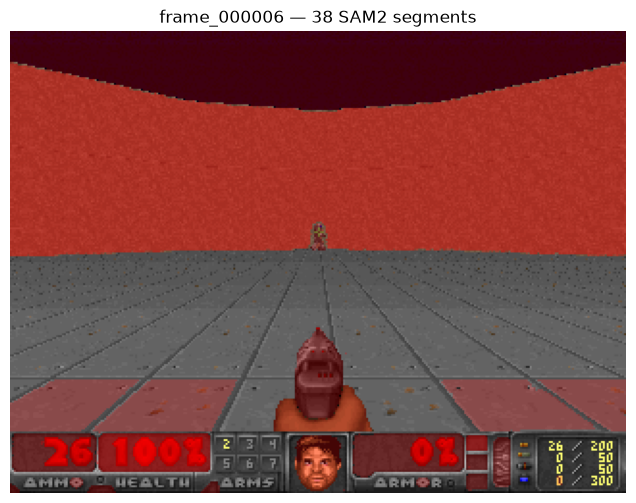

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


game_name = "vizdoom__defend_center"
frame_name = "frame_000006"

frame_path = f"../data/extracted_frames/{game_name}/{frame_name}.png"
segment_dir = f"../data/segmentation/{game_name}/{frame_name}"

frame = np.array(Image.open(frame_path).convert("RGB"))

with open(os.path.join(segment_dir, "segments.json")) as f:
    metadata = json.load(f)

print("Source frame:", metadata["source_frame"])
print("Number of segments:", metadata["num_segments"])

plt.figure(figsize=(8, 6))
plt.imshow(frame)

for segment in metadata["segments"]:
    mask = np.load(
        os.path.join(
            segment_dir,
            segment["mask_path"],
        )
    )

    overlay = np.zeros((*mask.shape, 4))
    overlay[mask] = [1, 0, 0, 0.25]

    plt.imshow(overlay)

plt.title(f"{frame_name} — {metadata['num_segments']} SAM2 segments")
plt.axis("off")
plt.show()

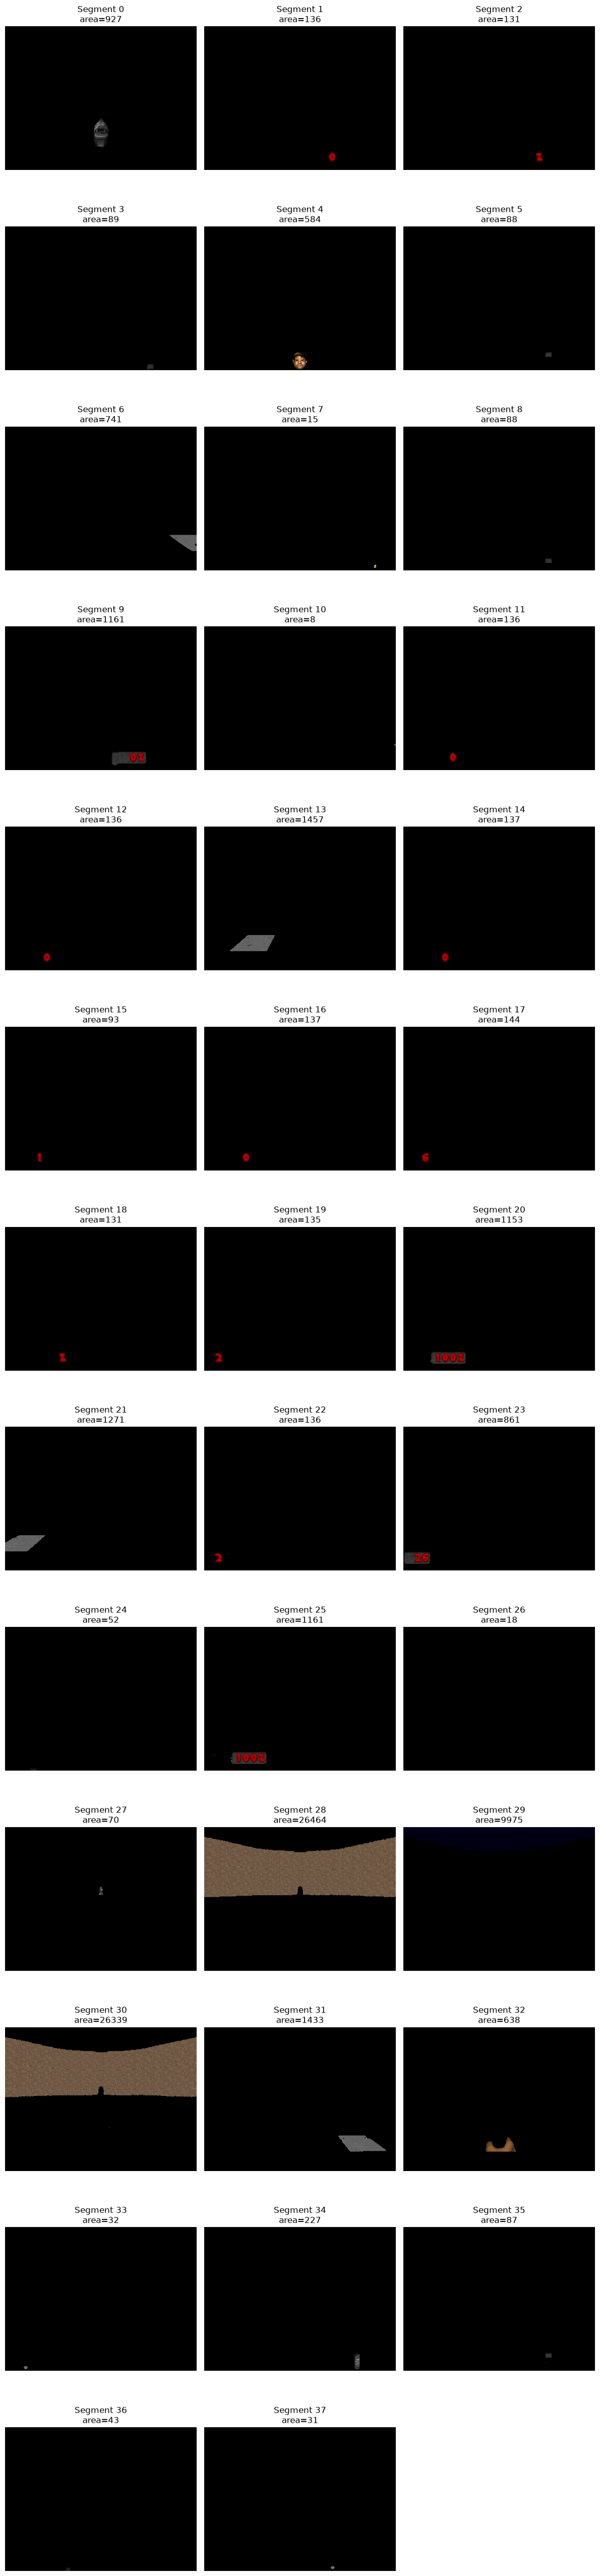

In [2]:
import math

segments = metadata["segments"]

columns = 3
rows = math.ceil(len(segments) / columns)

plt.figure(figsize=(columns * 4, rows * 4))

for i, segment in enumerate(segments):
    mask = np.load(
        os.path.join(
            segment_dir,
            segment["mask_path"],
        )
    )

    masked = np.zeros_like(frame)
    masked[mask] = frame[mask]

    plt.subplot(rows, columns, i + 1)
    plt.imshow(masked)

    plt.title(
        f"Segment {segment['segment_id']}\n"
        f"area={segment['area']}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()